# Lab 5
February 17, 2026

## Part 1. Setup + data loading
### 1.1. Import + environment check

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mapclassify

print("geopandas:", gpd.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("mapclassify:", mapclassify.__version__)

geopandas: 1.1.2
pandas: 3.0.0
numpy: 2.4.2
matplotlib: 3.10.8
mapclassify: 2.10.0


### 1.2. Read + inspect polygons

In [2]:
gdf = gpd.read_file('raw/Mecklenburg_BlckGrp.shp')
print('CRS:', gdf.crs)
print('Bounds:', gdf.total_bounds)
print('Columns:', list(gdf.columns))
print(gdf.head())

CRS: EPSG:26917
Bounds: [ 494692.6536 3873242.3533  540927.2319 3930137.1939]
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOID', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area', 'geometry']
  STATEFP COUNTYFP TRACTCE BLKGRPCE         GEOID       NAMELSAD  MTFCC  \
0      37      119  005611        1  371190056111  Block Group 1  G5030   
1      37      119  005713        2  371190057132  Block Group 2  G5030   
2      37      119  006105        1  371190061051  Block Group 1  G5030   
3      37      119  001916        1  371190019161  Block Group 1  G5030   
4      37      119  005714        3  371190057143  Block Group 3  G5030   

  FUNCSTAT      ALAND   AWATER     INTPTLAT      INTPTLON    Shape_Leng  \
0        S   711361.0      0.0  +35.3222959  -080.6954810   4957.576001   
1        S  6361753.0  21382.0  +35.1431850  -080.6519109  14481.340124   
2        S  7581166.0  82507.0  +35.3413691  -080.9008142  13137.

In [3]:
pop = pd.read_csv('raw/Pop_Mecklenburg.csv')
pop['GEO_ID'] = pop['GEO_ID'].astype(str)
medAge = pd.read_csv('raw/MedAge_Mecklenburg.csv')
medAge['GEO_ID'] = medAge['GEO_ID'].astype(str)
medAge = medAge.rename(columns={'Total': 'medAgeT', 'Male': 'medAgeM', 'Female': 'medAgeF'})

In [4]:
WORK_EPSG = 'EPSG:2264' # NAD83 / North Carolina (ftUS)
gdf_m = gdf.to_crs(WORK_EPSG)

gdf_m['area_sqmi'] = gdf_m.geometry.area / 27878400

## Part 2. Univariate choropleth
### 2.1. Clean the field you will map

In [5]:
gdf_join = gdf_m[['GEOID', 'geometry', 'area_sqmi']].merge(
    pop, left_on='GEOID', right_on='GEO_ID', how='left',
).drop(columns=['GEO_ID'])

gdf_join = gdf_join.merge(
    medAge, left_on='GEOID', right_on='GEO_ID', how='left',
).drop(columns=['GEO_ID'])

gdf_join['popDen'] = gdf_join['B01001_001E'] / gdf_join['area_sqmi']

gdf_join = gdf_join.replace(-666666666, np.nan)
gdf_join['medAgeT'] = gdf_join['medAgeT'].fillna(0)

VAR = 'popDen'
gdf_join[VAR] = pd.to_numeric(gdf_join[VAR], errors='coerce')

print('Missing values:', gdf_join[VAR].isna().sum())
print(gdf_join[VAR].describe())

Missing values: 0
count      624.000000
mean      3741.402290
std       3471.200659
min          0.000000
25%       1759.748374
50%       3010.186362
75%       4446.063429
max      39336.386594
Name: popDen, dtype: float64


In [6]:
gdf_join

,GEOID,geometry,area_sqmi,B01001_001E,medAgeT,medAgeM,medAgeF,popDen
0,371190056111,"POLYGON ((1491340.204 578131.34, 1491350.619 5...",0.274587,709,48.3,37.9,52.7,2582.059919
1,371190057132,"POLYGON ((1496830.4 509419.208, 1496943.462 50...",2.463914,2116,44.5,45.2,42.5,858.796269
2,371190061051,"POLYGON ((1429045.804 585655.763, 1429088.454 ...",2.958201,2730,37.5,37.4,37.7,922.858096
3,371190019161,"POLYGON ((1490688.85 532065.854, 1490705.876 5...",0.688490,1642,37.1,37.0,38.1,2384.930903
4,371190057143,"POLYGON ((1513554.497 521878.527, 1513567.327 ...",2.500052,1497,52.2,51.6,53.0,598.787518
...,...,...,...,...,...,...,...,...
619,371190016092,"POLYGON ((1477117.396 540264.225, 1477364.897 ...",0.519069,2285,35.4,30.5,41.8,4402.112255
620,371190030062,"POLYGON ((1450170.959 508809.655, 1450171.933 ...",0.550284,2326,40.7,42.1,38.9,4226.911945
621,371190057142,"POLYGON ((1504850.64 522214.737, 1505292.868 5...",3.543661,1410,51.1,50.8,51.3,397.893642
622,371190040001,"POLYGON ((1433460.596 546382.492, 1433468.326 ...",0.714156,565,43.4,37.8,43.6,791.143206


### 2.2. Plot a choropleth with a classification scheme

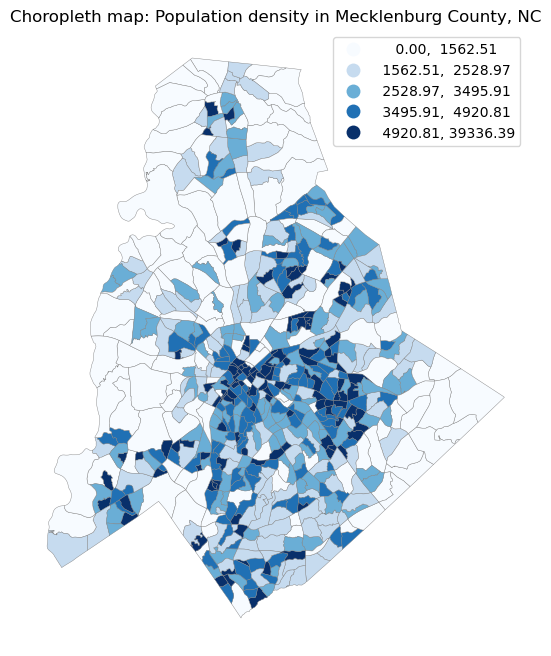

In [7]:
ax = gdf_join.plot(
    column=VAR,
    scheme='Quantiles',
    k=5,
    cmap='Blues',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    figsize=(10, 8),
)
ax.set_title(f'Choropleth map: Population density in Mecklenburg County, NC')
ax.set_axis_off()
plt.show()

### 2.3. Optional: add a basemap (contextily)

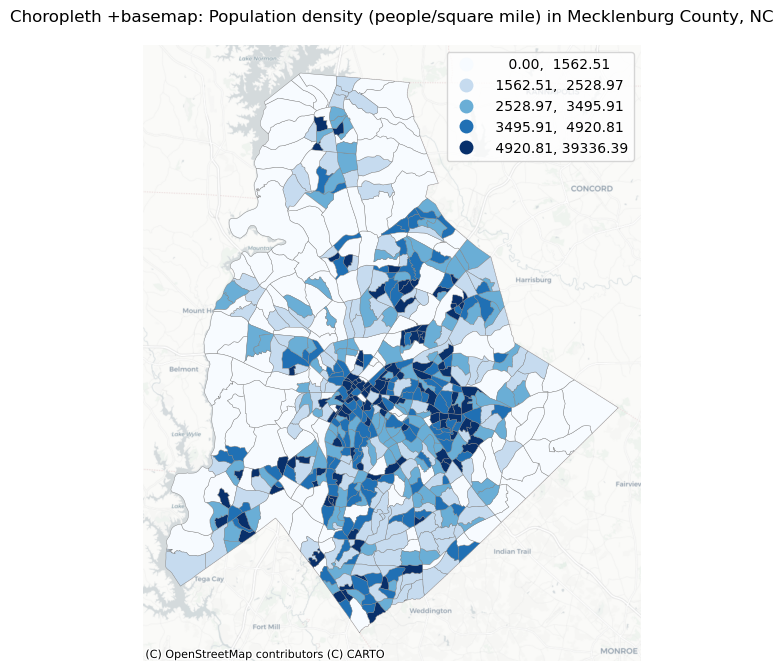

In [8]:
import contextily as cx

gdf_web = gdf_join.to_crs(epsg=3857)

ax = gdf_web.plot(
    column=VAR,
    scheme='Quantiles',
    k=5,
    cmap='Blues',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    figsize=(10, 8),
)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title(f'Choropleth +basemap: Population density (people/square mile) in Mecklenburg County, NC')
ax.set_axis_off()
plt.show()

## Part 3. Bivariate choropleth
### 3.1. Create bivariate classes (3x3 quantiles)

In [9]:
X = "popDen"
Y = "medAgeT" # <-- change
N = 3 # number of bins per variable (3 -> 3x3)
gdf_join[X] = pd.to_numeric(gdf_join[X], errors="coerce")
gdf_join[Y] = pd.to_numeric(gdf_join[Y], errors="coerce")
# Quantile bins (0..N-1). duplicates='drop' avoids errors if many ties.
gdf_join["x_bin"] = pd.qcut(gdf_join[X], N, labels=False, duplicates="drop")
gdf_join["y_bin"] = pd.qcut(gdf_join[Y], N, labels=False, duplicates="drop")
# Combine bins into one class ID (row-major)
gdf_join["bi_class"] = gdf_join["y_bin"] * N + gdf_join["x_bin"]

### 3.2. Map the bivariate classes to colors

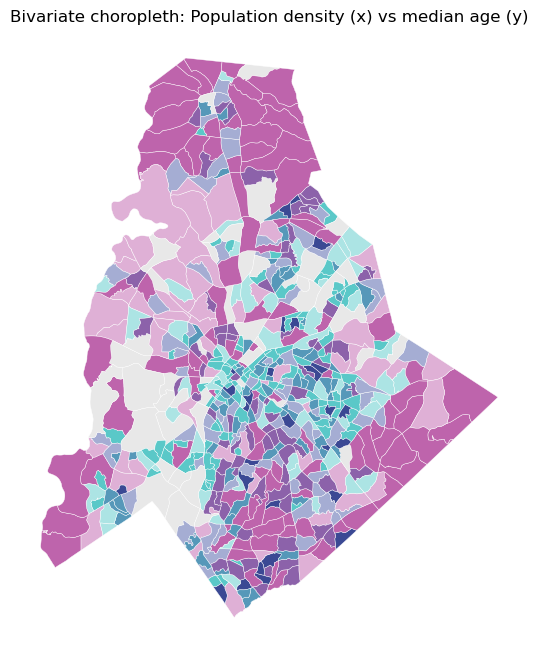

In [10]:
# 3x3 bivariate palette (row-major: y from low->high, x from low->high)
palette = [
    "#e8e8e8", "#ace4e4", "#5ac8c8",
    "#dfb0d6", "#a5add3", "#5698b9",
    "#be64ac", "#8c62aa", "#3b4994",
]

def class_to_color(v):
    if pd.isna(v):
        return "#dddddd"
    return palette[int(v)]

gdf_join["bi_color"] = gdf_join["bi_class"].apply(class_to_color)

ax = gdf_join.plot(color=gdf_join["bi_color"], linewidth=0.3, edgecolor="white", figsize=(10, 8))
ax.set_title(f"Bivariate choropleth: Population density (x) vs median age (y)")
ax.set_axis_off()
plt.show()

### 3.3. Build a bivariate legend (2D key)

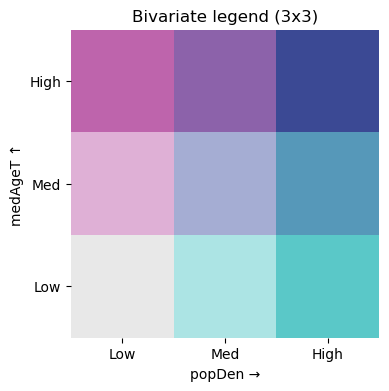

In [11]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(4, 4))

for y in range(N):
    for x in range(N):
        idx = y * N + x
        ax.add_patch(Rectangle((x, y), 1, 1, facecolor=palette[idx], edgecolor='none'))

ax.set_xlim(0, N)
ax.set_ylim(0, N)
ax.set_aspect('equal')

# Minimal labeling (edit these to match your variables)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_xticklabels(["Low", "Med", "High"])
ax.set_yticklabels(["Low", "Med", "High"])
ax.set_xlabel(X + " →")
ax.set_ylabel(Y + " ↑")

# Clean look
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title('Bivariate legend (3x3)')
plt.show()

## Part 4. Cartograms
### 4.1. Prepare the cartogram field

In [12]:
CART_FIELD = 'popDen'

gdf_join[CART_FIELD] = pd.to_numeric(gdf_join[CART_FIELD], errors="coerce")
gdf_join = gdf_join.dropna(subset=[CART_FIELD]).copy()

# Cartograms require positive values
gdf_join = gdf_join[gdf_join[CART_FIELD] > 0].copy()
print(gdf_join[CART_FIELD].describe())

count      622.000000
mean      3753.432523
std       3470.275571
min        107.282817
25%       1771.849965
50%       3012.265553
75%       4448.110825
max      39336.386594
Name: popDen, dtype: float64


### 4.2. Contiguous cartogram

Average residual area error: 0.2194889816643617


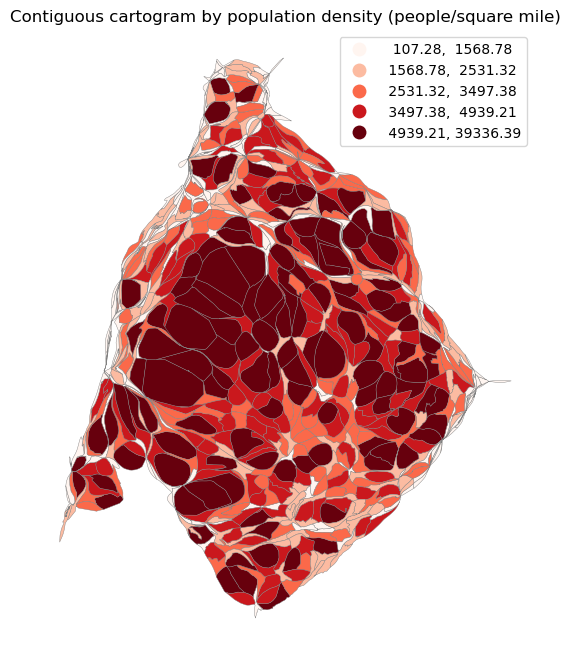

In [24]:
import cartogram

c = cartogram.Cartogram(
    gdf_join,
    CART_FIELD,
    max_iterations=10,
    max_average_error=0.10
)

print('Average residual area error:', c.average_error)

ax = c.plot(
    column=CART_FIELD,
    scheme='Quantiles',
    k=5,
    cmap='Reds',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    figsize=(10, 8),
)
ax.set_title(f'Contiguous cartogram by population density (people/square mile)')
ax.set_axis_off()
plt.show()

### 4.3. Fallback: simple non-contiguous cartogram (scale polygons)

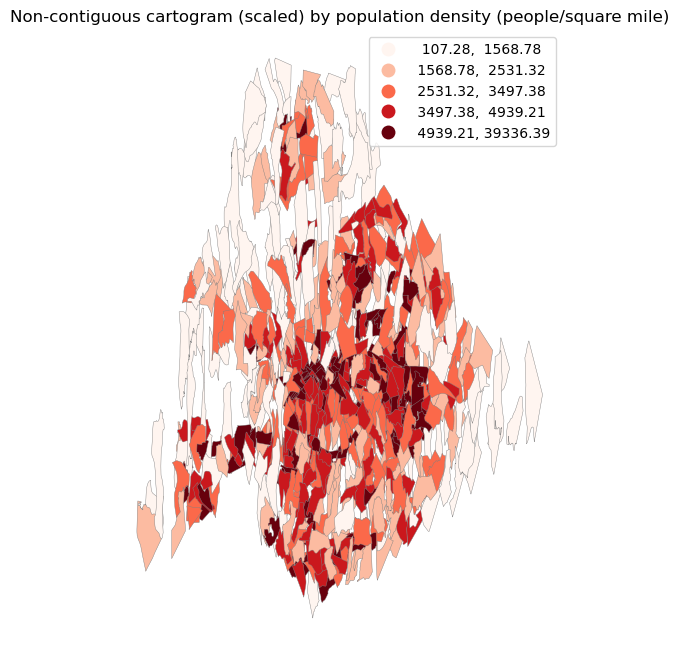

In [23]:
from shapely.affinity import scale

vals = gdf_join[CART_FIELD].to_numpy()
factors = np.sqrt(vals / np.nanmean(vals))

scaled_geoms = [
    scale(geom, xfact=f, yfact=y, origin='center') for geom, f in zip(gdf_join.geometry, factors)
]

gdf_scaled = gdf_join.copy()
gdf_scaled['geometry_scaled'] = scaled_geoms
gdf_scaled = gdf_scaled.set_geometry('geometry_scaled')

ax = gdf_scaled.plot(
    column=CART_FIELD,
    scheme='Quantiles',
    k=5,
    cmap='Reds',
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    figsize=(10, 8),
)
ax.set_title(f'Non-contiguous cartogram (scaled) by population density (people/square mile)')
ax.set_axis_off()
plt.show()